# ECG heartbeat classification

**Problem:** Given one recorded and preprocessed heartbeat, predict its beat category: **N, S, V, F, or Q**.

**Prerequisites:** basic supervised learning, Python arrays, and train/test splits. No prior cardiology knowledge is assumed.

## How this notebook explains the problem

1. Follow a clinical review workflow.
2. Learn what an electrocardiogram (ECG), QRS complex, and R-peak represent.
3. Follow the steps used to extract one beat from a continuous recording.
4. Inspect one input row and its waveform.
5. Learn what the five labels mean medically.
6. State the prediction target, evaluation plan, and limits.

## 1. Why classify heartbeats?

A clinician reviewing a long ECG recording may need to find beats with unusual electrical patterns. A research classifier can suggest a **beat type for review** after another process has located each beat.

The workflow for this dataset is:

**Recorded ECG → beat located and extracted → waveform prepared → model predicts a category → person reviews the result**

The **clinical purpose** is to help organize review of recorded beats. The **computational task** in this notebook starts at the prepared waveform: assign it one of five labels. The model does not find beats in a continuous recording, diagnose a patient, or recommend treatment.

## 2. What does an ECG measure?

An **electrocardiogram (ECG)** records changes in electrical activity at the body surface while the heart beats. It produces a signal: a sequence of measurements in time.

- A **recording** contains many beats over time.
- A **heartbeat segment** is a short portion of that recording around one beat.
- The segment's *shape* is called its **waveform**. Different electrical activation patterns can change that shape.
- A **beat label** describes one annotated beat. It is not a label for the whole recording or person.

**Key distinction:** this task classifies a beat that has **already been segmented**. Detecting where beats begin in an unprocessed ECG is a separate task.

### The QRS complex and the R-peak

A typical ECG beat has three recognizable parts. They are **electrical events within one beat**, not three separate beats:

| Part | What it represents | How it often looks |
|---|---|---|
| **P wave** | Electrical activation of the upper chambers (**atria**) | A small, rounded bump |
| **QRS complex** | Electrical activation of the lower chambers (**ventricles**) | A sharp group of deflections |
| **T wave** | Electrical recovery of the ventricles | A broader bump after the QRS complex |

Within the QRS complex, **Q** is a downward deflection before the main upward deflection, **R** is the upward deflection, and **S** is a downward deflection after it. The **R-peak** is the top of R. In a typical lead II tracing it provides a convenient time marker for a beat. Real ECGs do not always have every letter clearly visible or an upright R-peak; their shapes vary by lead and beat type.

The following plot is a **synthetic teaching sketch**, not a patient recording or a template for diagnosing a beat. Its horizontal axis is time relative to the R-peak; the vertical values are arbitrary.

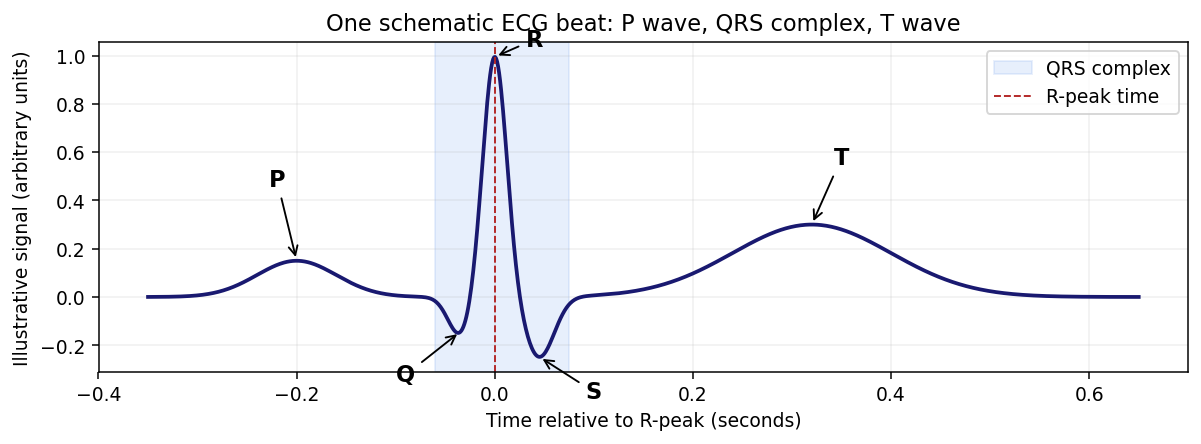

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic illustration only: sums of smooth bumps, not clinical ECG data.
t = np.linspace(-0.35, 0.65, 1000)
def bump(center, width, height):
    return height * np.exp(-0.5 * ((t - center) / width) ** 2)

wave = (bump(-0.20, 0.04, 0.15)   # P
        + bump(-0.035, 0.012, -0.16)  # Q
        + bump(0.0, 0.012, 1.0)       # R
        + bump(0.045, 0.015, -0.25)  # S
        + bump(0.32, 0.08, 0.30))     # T

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(t, wave, color="midnightblue", linewidth=2)
ax.axvspan(-0.06, 0.075, color="cornflowerblue", alpha=0.15, label="QRS complex")
for letter, x, text_xy in [
    ("P", -0.20, (-0.22, 0.46)),
    ("Q", -0.035, (-0.09, -0.35)),
    ("R", 0.0, (0.04, 1.04)),
    ("S", 0.045, (0.10, -0.42)),
    ("T", 0.32, (0.35, 0.55)),
]:
    y = wave[np.argmin(np.abs(t - x))]
    ax.annotate(letter, xy=(x, y), xytext=text_xy,
                fontsize=12, fontweight="bold", ha="center",
                arrowprops={"arrowstyle": "->", "lw": 1})
ax.axvline(0, color="firebrick", linestyle="--", linewidth=1, label="R-peak time")
ax.set(xlabel="Time relative to R-peak (seconds)",
       ylabel="Illustrative signal (arbitrary units)",
       title="One schematic ECG beat: P wave, QRS complex, T wave")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Read the plot:** the blue shaded region is the **QRS complex**. Its tall **R-peak** is at time zero; “R-peak time” means the time coordinate of that peak. The nearby P and T waves belong to the same illustrated beat. The ECG measures electrical activity that triggers contraction; it does not directly measure blood flow. [MedlinePlus ECG explanation](https://medlineplus.gov/lab-tests/electrocardiogram/)

## 3. How is one beat extracted from a continuous ECG?

### What does “sampling” mean?

An ECG lead records a **voltage difference detected by electrodes on the body** as the heart's electrical activity changes. **Sampling** means recording that signal's value at regularly spaced instants. Each recorded value is one **sample**; it is not one heartbeat or the magnitude of one isolated impulse. In an original ECG recording, voltage can be expressed in **millivolts (mV)**. [PhysioNet's guide to signals and samples](https://physionet.org/physiotools/wpg/wpg_3.htm)

#### What is ECG lead II?

A **lead** is one electrical **view** of the heart. Different electrode comparisons produce different waveforms of the same heartbeat. In **standard lead II**, the ECG compares the left-leg electrode (**positive**) with the right-arm electrode (**negative**): approximately **left-leg voltage minus right-arm voltage**. “II” names the view; it does not mean a second heartbeat or two samples. [ECG lead description](https://www.ncbi.nlm.nih.gov/books/NBK354/)

- In most original MIT-BIH recordings, the corresponding signal is **modified lead II (MLII)**. Its electrodes were placed on the **torso** in positions chosen to give a view similar to standard limb lead II; the other recorded channel usually had a different view. [PhysioNet lead FAQ](https://archive.physionet.org/faq.shtml)
- The [source paper](https://arxiv.org/pdf/1805.00794) calls its model input “lead II.” The [MIT-BIH database directory](https://physionet.org/physiobank/database/html/mitdbdir/intro.htm) adds that most upper-channel recordings were MLII, with some exceptions using other lead placements. The beat CSV does not identify the source lead of an individual row.

**Lead II tells us which voltage view is measured; the sampling rate tells us how often that view is measured.**

The original MIT-BIH recordings were sampled **360 times per second**. The [source paper](https://arxiv.org/pdf/1805.00794) used ECG lead II resampled to **125 times per second** for this task. That means one value every **1/125 second = 0.008 second = 8 milliseconds**: at about 0 ms, 8 ms, 16 ms, and so on. Connecting successive values in time order produces the waveform. The Kaggle CSV values were subsequently scaled, so a value such as `0.8` in a beat row is a **processed signal value, not 0.8 mV**.

### Extraction steps

The source paper describes the following preprocessing. It was done **before** the Kaggle CSVs were created.

1. **Take a 10-second section of the continuous ECG.** It contains several beats. At 125 samples per second, a 10-second section contains about **1,250 signal values**.
2. **Scale the signal values to the range 0–1.** This changes the numerical amplitude scale used for the next step; it does not identify a beat by itself.
3. **Find candidate R-peaks.** A *local maximum* is a point higher than the nearby points. The paper checks these maxima and keeps strong candidates above **0.9** on the normalized scale. “Candidate” matters: a simple peak-finding rule can make errors on unusual or noisy signals.
4. **Measure R–R intervals.** An R–R interval is the time from one detected R-peak to the next. The **median** (middle value) of these intervals in the 10-second section is called **\(T\)** and estimates the typical time between beats there.
5. **Extract a short signal piece for each R-peak.** Its duration is **\(1.2T\)**. This piece contains the beat and nearby signal. The paper specifies the duration but does not give a precise before-versus-after offset for the cut in its written steps.
6. **Make every input 187 positions long.** The **125 samples per second** tells us the spacing between measurements; **187** is the fixed number of waveform positions in each CSV row. At that sampling rate, 187 positions could hold about **187 / 125 = 1.50 seconds** of measured signal. A shorter extracted piece is filled out with **zero padding**, so its 187 values do **not** all represent measured ECG. The **188th column is the class label**, mapped from the original beat annotation. The source paper specifies a fixed length but does not explain why this release uses exactly 187 signal positions.



## 4. What data do we have?

We use the **MIT-BIH portion** of the Kaggle [ECG Heartbeat Categorization Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat), which is derived from the [MIT-BIH Arrhythmia Database](https://physionet.org/content/mitdb/1.0.0/). The original database has annotated, continuous ECG recordings from **47 people**. The supplied CSVs contain processed beat segments; they do **not** contain those full recordings or patient identifiers.

**One row means one beat:**

| Columns | Meaning |
|---|---|
| `0`–`186` | 187 ordered values from the beat waveform |
| `187` | Reference label: an integer from `0` to `4` |

According to the Kaggle dataset card, beat segments were cropped, downsampled to **125 samples per second**, and zero-padded where needed to a common length. Padding zeros are added values, **not** evidence that the heart's electrical activity was zero. The waveform has already been prepared; this notebook is not working from raw ECG recordings.

| File in `../data/ecg_hb_clf/` | Beat rows | Use |
|---|---:|---|
| `mitbih_train.csv` | 87,554 | Model development |
| `mitbih_test.csv` | 21,892 | Supplied test set |
| `ptbdb_normal.csv` and `ptbdb_abnormal.csv` | 14,552 combined | Separate PTB task; not used for these five labels |

The MIT-BIH CSVs contain **109,446 rows in total**. These numbers count **beats, not patients**.

### Look at one real input

Run the next cell to plot the **first row of the training CSV**. It reads only one row, so it does not load the full dataset. The x-axis is the position within the prepared segment; the y-axis shows its processed signal value, not an original voltage measurement.

This is **one example**, not the average or defining shape of its class. The label is read from the last column.

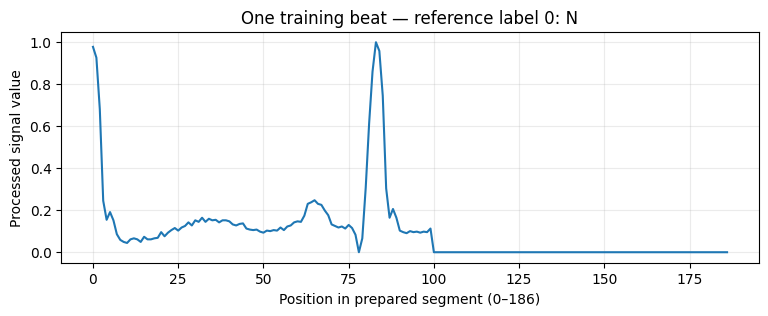

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Works when launched from this notebook's folder or the repository root.
candidates = [
    Path("../data/ecg_hb_clf/mitbih_train.csv"),
    Path("module2/lectures/data/ecg_hb_clf/mitbih_train.csv"),
]
train_path = next((path for path in candidates if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("Could not find mitbih_train.csv in module2/lectures/data/ecg_hb_clf/")

first_beat = pd.read_csv(train_path, header=None, nrows=1).iloc[0]
signal = first_beat.iloc[:187].astype(float).to_numpy()
label = int(first_beat.iloc[187])
label_names = {0: "N", 1: "S", 2: "V", 3: "F", 4: "Q"}

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(187), signal, linewidth=1.5)
ax.set(xlabel="Position in prepared segment (0–186)",
       ylabel="Processed signal value",
       title=f"One training beat — reference label {label}: {label_names[label]}")
ax.grid(alpha=0.25)
plt.show()

**Read the plot:** the model receives the sequence of 187 values, in order. The final CSV value is the **answer used for training**, not another signal measurement. The flat tail in this example is zero padding added during preprocessing. Signal shape can help distinguish categories, but a single plot cannot establish a diagnosis.

## 5. What do the labels mean medically?

A usual heartbeat begins with an electrical impulse in the **sinus node** in an upper chamber (**atrium**) and then activates the lower chambers (**ventricles**).

- **Ectopic** means an impulse begins from another site.
- **Premature** means a beat occurs earlier than expected.
- **Escape** means a backup impulse occurs after the usual impulse is delayed or absent.
- **Fusion** means two activation pathways contribute to one beat.

The CSV labels are **broad groups** of original beat annotations. They describe the type of an individual beat, not a complete disease or rhythm diagnosis.

| CSV value | Group | What it means | What it does **not** mean |
|---|---|---|---|
| **0 — N** | Normal / non-ectopic group | Often a sinus beat from the heart's usual pacemaker. This broad group can also include bundle branch block and escape-beat annotations. | The entire ECG or patient is healthy. |
| **1 — S** | Supraventricular ectopic group | A beat beginning **above the ventricles**, often in an atrium or near the atrioventricular junction. An atrial premature beat is one example. | The patient necessarily has a sustained rhythm such as atrial fibrillation. |
| **2 — V** | Ventricular ectopic group | A beat beginning **in the ventricles**. A premature ventricular contraction is one example; a ventricular escape beat may also belong here. | One V beat proves ventricular tachycardia. |
| **3 — F** | Fusion of normal and ventricular activation | Normal and ventricular impulses activate the ventricles together, producing one blended beat. | A fusion with a pacemaker; that is grouped elsewhere. |
| **4 — Q** | Unknown / other group | Includes **paced beats** initiated by an implanted pacemaker, paced-normal fusion, and beats that could not be classified. | Every Q beat is unreadable or medically unclassifiable. |

**Why the letters can be confusing:** in the [original MIT-BIH annotation legend](https://physionet.org/physiobank/database/html/mitdbdir/intro.htm), `Q` is one specific symbol for an unclassifiable beat and `/` marks a paced beat. In these CSVs, **class 4 (Q) is a wider grouped category**. Likewise, each of the other four CSV classes may group multiple original symbols. The CSV does not say which original subtype a particular row had.

### Two examples of interpreting a label

1. If a row ends in **`2`**, its reference label is **V**. The model should learn to recognize features of the waveform associated with the ventricular ectopic group. The row alone does not establish a patient's diagnosis.
2. If a row ends in **`4`**, its reference label is **Q**. We know its **group**, but cannot tell from this CSV whether it was a paced beat, paced-normal fusion, or an unclassifiable beat.

## 6. What exactly are we predicting?

| Question | Answer for this problem |
|---|---|
| **Input** | One prepared sequence of 187 ECG values |
| **Target** | One of five beat labels: `0/N`, `1/S`, `2/V`, `3/F`, `4/Q` |
| **Unit of analysis** | A beat row, not a person or full recording |
| **When is the prediction made?** | After the beat has been recorded, extracted, and preprocessed |
| **Intended user here** | Students and researchers evaluating an educational prototype; any clinical use would require a separate workflow and validation |

This is **supervised, multiclass time-series classification**. It is not forecasting, beat detection, or classification of the separate PTB files.

## 7. How will we tell whether a solution works?

The classes are uneven. In the supplied training set, **72,471 of 87,554 beats (82.77%) are N**, while **641 (0.73%) are F**. A model that always says N could appear accurate while missing every other category.

A useful evaluation will therefore include:

1. A simple baseline, such as always predicting the most common training label.
2. A **confusion matrix** showing which classes are confused.
3. **Sensitivity (recall), precision, and F1 for each class**, especially the rare classes.
4. **Macro F1**, which averages class-level F1 scores equally, alongside overall accuracy.
5. If the model produces probabilities, an assessment of their **calibration** and any review threshold.

**Important limit:** these CSVs contain no patient or recording IDs, so they cannot show whether the supplied train and test sets contain beats from the same people. They support a beat-level benchmark, not a demonstrated result on new patients. A stronger study would use the original recordings and annotations to split by patient or recording **before** extracting beats. This educational model must not be treated as a clinical diagnostic device.

## Check your understanding

1. What is the difference between **one beat row** and a **patient's ECG recording**?
2. Why does the 188th CSV value serve as a label rather than an ECG measurement?
3. Give one example of an original beat type that could belong to **Q**. Why is “Q = unclassifiable” incomplete?
4. What does an R–R interval measure, and why does the extraction use its median?
5. Why could **accuracy** look good even if the model rarely identifies F beats?

## Sources

- [ECG Heartbeat Categorization Dataset — Kaggle data card](https://www.kaggle.com/datasets/shayanfazeli/heartbeat): processed CSVs, sample rate, class mapping.
- [MIT-BIH Arrhythmia Database — PhysioNet](https://physionet.org/content/mitdb/1.0.0/): original recordings and participants.
- [MIT-BIH annotation legend — PhysioNet](https://physionet.org/physiobank/database/html/mitdbdir/intro.htm): meanings of original beat symbols.
- [Kachuee, Fazeli, and Sarrafzadeh (2018)](https://arxiv.org/pdf/1805.00794): source classification study and preprocessing steps.
- [MedlinePlus ECG explanation](https://medlineplus.gov/lab-tests/electrocardiogram/): P wave, QRS complex, and T wave.